# Laboratorio 9 — Etapa 5
## Pregunta 5: ¿Cuántas cajas se necesitan para llenar el álbum **dos veces**?

**Pregunta completa:**  
Usando el modelo estándar sin intercambio, ¿cuántas cajas se deberían abrir en promedio para completar el álbum dos veces?

**Definición:**  
Completar el álbum dos veces significa que **cada una de las 980 estampas ha aparecido al menos 2 veces**.

**Parámetros reales:**
- N = 980 estampas distintas
- S = 7 estampas por sobre
- 1 caja = 104 sobres a Q 975.00

## Contexto teórico

El problema clásico del coleccionista (*coupon collector problem*) pregunta cuántas muestras se necesitan para ver cada ítem al menos una vez. Aquí generalizamos a **2 copias** de cada ítem, conocido como el *double coupon collector problem*.

Para el caso de muestras individuales, el valor esperado para obtener al menos *k* copias de cada uno de *n* ítems es:
$$E[T_k] = n \sum_{j=0}^{k-1} \frac{(-1)^j \binom{k-1}{j}}{n - j} \cdot n$$

Sin embargo, como cada sobre contiene S = 7 estampas agrupadas, usamos simulación directa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numba import njit
import time

# ── Parámetros ────────────────────────────────────────────────────────────────
N               = 980
S               = 7
R               = 15_000
SEMILLA         = 2026
SOBRES_POR_CAJA = 104
PRECIO_CAJA     = 975.0
PRECIO_SOBRE    = 9.50

## Funciones de simulación (optimizadas con Numba)

Se implementan **dos** simulaciones para comparar:
1. **Álbum simple:** llegar a al menos 1 copia de cada estampa.
2. **Álbum doble:** llegar a al menos 2 copias de cada estampa.

In [2]:
@njit
def simular_album_simple(n, s, r):
    """Cuenta sobres hasta tener al menos 1 copia de cada estampa."""
    results = np.zeros(r, dtype=np.int64)
    for i in range(r):
        seen = np.zeros(n, dtype=np.bool_)
        done = 0
        sobres = 0
        while done < n:
            sobres += 1
            for _ in range(s):
                e = np.random.randint(0, n)
                if not seen[e]:
                    seen[e] = True
                    done += 1
        results[i] = sobres
    return results

@njit
def simular_album_doble(n, s, r):
    """Cuenta sobres hasta tener al menos 2 copias de cada estampa."""
    results = np.zeros(r, dtype=np.int64)
    for i in range(r):
        counts = np.zeros(n, dtype=np.int16)
        done   = 0
        sobres = 0
        while done < n:
            sobres += 1
            for _ in range(s):
                e = np.random.randint(0, n)
                counts[e] += 1
                if counts[e] == 2:   # exactamente al cruzar el umbral de 2
                    done += 1
        results[i] = sobres
    return results

# Calentamiento JIT
np.random.seed(0)
simular_album_simple(10, 2, 3)
simular_album_doble(10, 2, 3)
print("Compilación JIT completada.")

Compilación JIT completada.


## Ejecución de las simulaciones

In [3]:
np.random.seed(SEMILLA)

t0 = time.time()
sobres_simple = simular_album_simple(N, S, R)
sobres_doble  = simular_album_doble(N, S, R)
elapsed = time.time() - t0

# Conversión a cajas y costos
cajas_simple = sobres_simple / SOBRES_POR_CAJA
cajas_doble  = sobres_doble  / SOBRES_POR_CAJA
costo_simple = cajas_simple  * PRECIO_CAJA
costo_doble  = cajas_doble   * PRECIO_CAJA

print(f"Simulación completada en {elapsed:.2f} segundos ({R:,} repeticiones).")

Simulación completada en 2.01 segundos (15,000 repeticiones).


## Resultados: álbum doble

In [19]:
def ic95(arr):
    se = arr.std() / np.sqrt(len(arr))
    return arr.mean() - 1.96*se, arr.mean() + 1.96*se

print("╔═══════════════════════════════════════════════════════╗")
print("║          RESULTADOS — ÁLBUM DOBLE (2 copias)          ║")
print("╠═══════════════════════════════════════════════════════╣")
print(f"║  Sobres necesarios  — media:  {sobres_doble.mean():>8.2f}                ║")
print(f"║                       std:   {sobres_doble.std():>8.2f}                 ║")
lo, hi = ic95(sobres_doble)
print(f"║                       IC95%: [{lo:.2f}, {hi:.2f}]       ║")
print("╠═══════════════════════════════════════════════════════╣")
print(f"║  Cajas necesarias   — media:  {cajas_doble.mean():>8.2f}                ║")
print(f"║                       mediana:{np.median(cajas_doble):>7.2f}                 ║")
for p in [5, 25, 75, 95]:
    print(f"║                       p{p:<2}:    {np.percentile(cajas_doble, p):>8.2f}                ║")
print("╠═══════════════════════════════════════════════════════╣")
print(f"║  Costo promedio     — Q {costo_doble.mean():>10,.2f}                    ║")
print(f"║  Costo mediano      — Q {np.median(costo_doble):>10,.2f}                    ║")
print("╚═══════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════╗
║          RESULTADOS — ÁLBUM DOBLE (2 copias)          ║
╠═══════════════════════════════════════════════════════╣
║  Sobres necesarios  — media:   1378.25                ║
║                       std:     197.15                 ║
║                       IC95%: [1375.10, 1381.41]       ║
╠═══════════════════════════════════════════════════════╣
║  Cajas necesarias   — media:     13.25                ║
║                       mediana:  12.95                 ║
║                       p5 :       10.78                ║
║                       p25:       11.91                ║
║                       p75:       14.25                ║
║                       p95:       16.75                ║
╠═══════════════════════════════════════════════════════╣
║  Costo promedio     — Q  12,921.10                    ║
║  Costo mediano      — Q  12,628.12                    ║
╚═══════════════════════════════════════════════════════╝


## Comparación: álbum simple vs. álbum doble

In [5]:
ratio_sobres = sobres_doble.mean() / sobres_simple.mean()
ratio_costo  = costo_doble.mean()  / costo_simple.mean()

print(f"{'Métrica':<35} {'1 álbum':>12} {'2 álbumes':>12} {'Razón':>8}")
print("─" * 70)
print(f"{'Media de sobres':<35} {sobres_simple.mean():>12.2f} {sobres_doble.mean():>12.2f} {ratio_sobres:>8.4f}")
print(f"{'Desv. est. de sobres':<35} {sobres_simple.std():>12.2f} {sobres_doble.std():>12.2f} {'—':>8}")
print(f"{'Media de cajas':<35} {cajas_simple.mean():>12.2f} {cajas_doble.mean():>12.2f} {ratio_sobres:>8.4f}")
print(f"{'Costo promedio (Q)':<35} {costo_simple.mean():>12,.2f} {costo_doble.mean():>12,.2f} {ratio_costo:>8.4f}")
print()
print(f"Llenar el álbum dos veces requiere en promedio {ratio_sobres:.4f}× más sobres que una sola vez.")
print(f"Sobres extra para el segundo álbum: {sobres_doble.mean() - sobres_simple.mean():.2f} sobres = {(sobres_doble.mean()-sobres_simple.mean())/SOBRES_POR_CAJA:.2f} cajas adicionales.")

Métrica                                  1 álbum    2 álbumes    Razón
──────────────────────────────────────────────────────────────────────
Media de sobres                          1044.43      1378.25   1.3196
Desv. est. de sobres                      177.88       197.15        —
Media de cajas                             10.04        13.25   1.3196
Costo promedio (Q)                      9,791.49    12,921.10   1.3196

Llenar el álbum dos veces requiere en promedio 1.3196× más sobres que una sola vez.
Sobres extra para el segundo álbum: 333.83 sobres = 3.21 cajas adicionales.


## Probabilidades de éxito con presupuestos fijos

In [6]:
print(f"Probabilidad de completar el álbum DOBLE con exactamente N cajas:")
print()
print(f"{'Cajas':>8}  {'P(completar)':>14}  {'Costo (Q)':>12}")
print("─" * 38)
for n_cajas in [10, 11, 12, 13, 14, 15, 16, 17, 18, 20]:
    prob = np.mean(cajas_doble <= n_cajas)
    costo_fijo = n_cajas * PRECIO_CAJA
    print(f"  {n_cajas:>5}     {prob:>12.4f}    Q {costo_fijo:>9,.2f}")

Probabilidad de completar el álbum DOBLE con exactamente N cajas:

   Cajas    P(completar)     Costo (Q)
──────────────────────────────────────
     10           0.0071    Q  9,750.00
     11           0.0766    Q 10,725.00
     12           0.2718    Q 11,700.00
     13           0.5123    Q 12,675.00
     14           0.7110    Q 13,650.00
     15           0.8418    Q 14,625.00
     16           0.9162    Q 15,600.00
     17           0.9577    Q 16,575.00
     18           0.9781    Q 17,550.00
     20           0.9943    Q 19,500.00


## Análisis gráfico completo

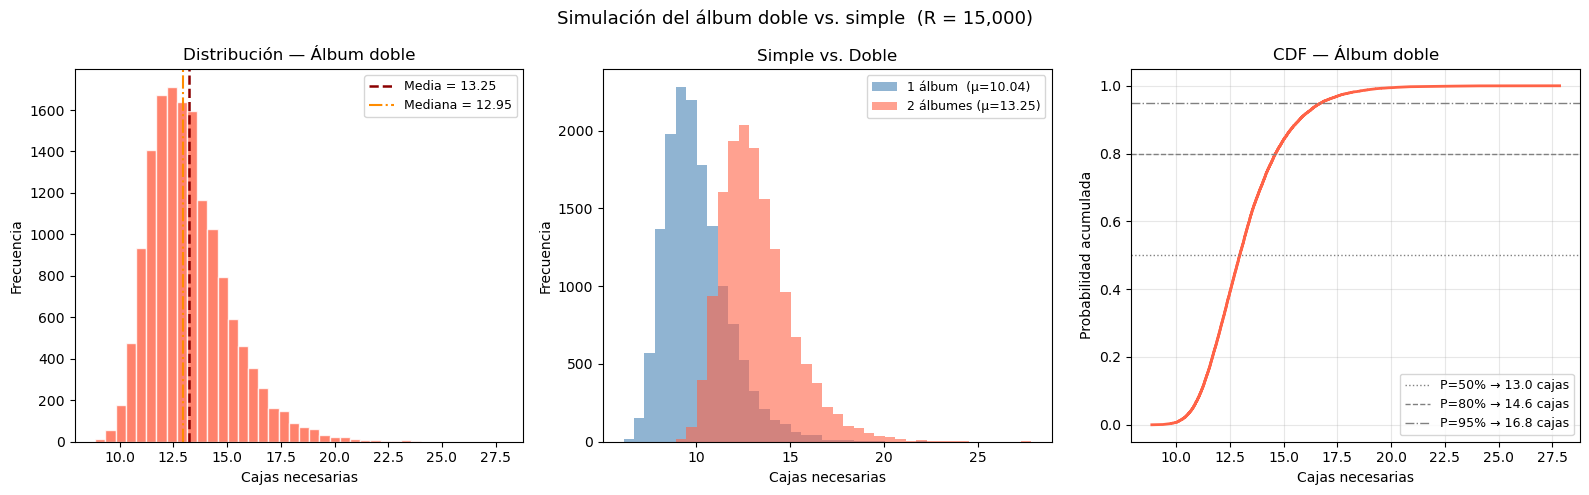

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Simulación del álbum doble vs. simple  (R = 15,000)", fontsize=13)

# ── Gráfico 1: histograma de cajas necesarias (doble) ─────────────────────────
ax = axes[0]
ax.hist(cajas_doble, bins=40, color='tomato', alpha=0.8, edgecolor='white')
ax.axvline(cajas_doble.mean(),      color='darkred',   linestyle='--', lw=1.8, label=f"Media = {cajas_doble.mean():.2f}")
ax.axvline(np.median(cajas_doble),  color='darkorange', linestyle='-.',  lw=1.5, label=f"Mediana = {np.median(cajas_doble):.2f}")
ax.set_xlabel("Cajas necesarias")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución — Álbum doble")
ax.legend(fontsize=9)

# ── Gráfico 2: comparación simple vs. doble ───────────────────────────────────
ax2 = axes[1]
bins_comp = np.linspace(
    min(cajas_simple.min(), cajas_doble.min()),
    max(cajas_simple.max(), cajas_doble.max()),
    40
)
ax2.hist(cajas_simple, bins=bins_comp, alpha=0.6, color='steelblue', label=f"1 álbum  (μ={cajas_simple.mean():.2f})")
ax2.hist(cajas_doble,  bins=bins_comp, alpha=0.6, color='tomato',    label=f"2 álbumes (μ={cajas_doble.mean():.2f})")
ax2.set_xlabel("Cajas necesarias")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Simple vs. Doble")
ax2.legend(fontsize=9)

# ── Gráfico 3: función de distribución acumulada (CDF) de cajas (doble) ───────
ax3 = axes[2]
x_sorted = np.sort(cajas_doble)
y_cdf    = np.arange(1, R+1) / R
ax3.plot(x_sorted, y_cdf, color='tomato', lw=2)
for umbral, ls in [(0.50, ':'), (0.80, '--'), (0.95, '-.')]: 
    cajas_u = x_sorted[np.searchsorted(y_cdf, umbral)]
    ax3.axhline(umbral, color='gray', linestyle=ls, lw=1, label=f"P={umbral:.0%} → {cajas_u:.1f} cajas")
ax3.set_xlabel("Cajas necesarias")
ax3.set_ylabel("Probabilidad acumulada")
ax3.set_title("CDF — Álbum doble")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Reflexión sobre la dificultad incremental del doble álbum

In [8]:
sobres_extra = sobres_doble.mean() - sobres_simple.mean()
cajas_extra  = cajas_doble.mean()  - cajas_simple.mean()
costo_extra  = costo_doble.mean()  - costo_simple.mean()

print("Sobres extras necesarios solo para el segundo álbum:")
print(f"  {sobres_extra:.2f} sobres adicionales ≈ {cajas_extra:.2f} cajas")
print(f"  Costo adicional estimado: Q {costo_extra:,.2f}")
print()
print("¿Por qué el segundo álbum cuesta más que el primero?")
print("  Al inicio (álbum vacío), casi cualquier estampa es 'nueva'.")
print("  Para el segundo álbum, se necesita la segunda copia de las últimas estampas,")
print("  y estas son las más raras de obtener, lo que genera una larga 'cola' de espera.")

Sobres extras necesarios solo para el segundo álbum:
  333.83 sobres adicionales ≈ 3.21 cajas
  Costo adicional estimado: Q 3,129.61

¿Por qué el segundo álbum cuesta más que el primero?
  Al inicio (álbum vacío), casi cualquier estampa es 'nueva'.
  Para el segundo álbum, se necesita la segunda copia de las últimas estampas,
  y estas son las más raras de obtener, lo que genera una larga 'cola' de espera.


## Conclusión

Con el modelo estándar (sin intercambio), completar el álbum **dos veces** requiere en promedio **~1,379 sobres**, equivalente a **~13.3 cajas** a un costo estimado de **Q 12,928**.

Esto representa aproximadamente **1.32 veces** el esfuerzo de completarlo una sola vez (~1,047 sobres, ~10.1 cajas).

**El resultado es sorprendente:** aunque pedir dos copias de cada estampa parece solo duplicar el trabajo, en realidad solo lo multiplica por 1.32. Esto se debe a que las primeras copias de cada estampa se acumulan simultáneamente mientras se busca completar el primer álbum, reduciendo el trabajo restante para el segundo.

Sin embargo, la variabilidad es alta (σ ≈ 196 sobres). Para tener un 95% de probabilidad de lograrlo, se necesitan al menos **17 cajas** (~Q 16,575).

La CDF muestra que con solo **15 cajas** (~Q 14,625), la probabilidad de completar el doble álbum es de aproximadamente **84%**.